# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# importar librerías

In [5]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage =  pd.read_csv('/datasets/usage.csv')#completa el código

In [6]:
plans.head() # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [7]:
users.head() # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [8]:
usage.head() # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [9]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage",usage.shape )

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [10]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [11]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [12]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [13]:
# cantidad de nulos para users
print("Cantidad de Nulos en users:\n", users.isna().sum())# Cantidad de valores nulos)
print("Proporción Nulos en users:\n", users.isna().mean()) # Proporción de valores nulos)

Cantidad de Nulos en users:
 user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción Nulos en users:
 user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [14]:
print("Cantidad de Nulos en usage:\n", usage.isna().sum()) 
print("Proporción Nulos en usage:\n", usage.isna().mean())# cantidad de nulos para usage

Cantidad de Nulos en usage:
 id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción Nulos en usage:
 id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- **RP** En el DF users, las columnas "city" y "churn_date" mantienen nulos, con una proporción del 11,7% y 88,3% respectivamente.
- **RP** En el DF usage, las columnas "duration","length" y "date" mantienen nulos, con una proporción del 55%, 44,7% y 0,01% respectivamente  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- **RP** columnas: "city": dejaria como nulos (dificil de imputar sin ingresar datos falsos, no afectan directamente al analisis)
  "churn_date":imputaria,columna con datos valiosos que demuestran los clientes activos en el servicio, cambiaria el ingreso de datos, demostrando su permanencia)
  "duration" Y "lenght": imputaria, columnas necesarias para el analisis
  "date": dejaria como nulos, su proporcion es minima y no influye en el analisis directamente

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [15]:
users.describe() # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` no presenta nulos, mantiene una std alta, entendible para un lista en ascenso identificadora de clientes.
- La columna `age`  Presencia de sentinels en MIN.(-999), no nulos.

In [16]:
usage.describe() # explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`no presentan nulos, mantienen std altas, porque ambas columnas son identificadoras y recorren un rango numerico por cada cliente, su min y max representan los valores reales de identificacion. 
- Las columnas "duration" y "length": presentan altas cantidades de datos nulos (posible MAR), su std en baja. demuestra un minimo normal para lo que representa pero sus maximos son de evaluacion, puede tratarse de un error o una posibilidad extraña de uso en duracion de llamada y longitud de sms.

In [17]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` presenta nulos, con 7 categorias unicas, donde la mas nombrada es "Bogotá" apareciendo 808 veces
- - La columna `plan` no presenta nulos, con 2 categorías unicas, donde la mas nombrada es "Básico" apareciendo 2595 veces

In [18]:
# explorar columna categórica de usage
usage['type'].describe()  # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta nulos, con 2 categorías unicas, siendo la mas nombra "text" con una aparición de 22092 veces.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels? y - ¿Qué acción tomarías?
  
- **RP** columna 'age' presenta sentinels, imputar
- columnas'duration' y 'length' evaluaria valores invalidos, por la cifra de sus maximos, puede ser un error o quiza un suceso extraño, tambien presentan nulos, los que evaluaria e imputaría ya que la falta de datos puede coincidir que la columna no describa la categoria. (duracion de llamada en la categoria texto)
- columna 'city existen valores nulos que eliminaria o los dejaria como nulos, imposible imputar sin inventar datos



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [19]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime (users['reg_date'], errors= "coerce", utc= True) # completa el código

In [20]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime (usage['date'], errors= "coerce", utc= True)# completa el código

In [21]:
users ['reg_date'].dt.year.unique()# Revisar los años presentes en `reg_date` de users


array([2022, 2026, 2023, 2024])

En `reg_date`, existen datos erroneos con la presencia del año 2026, ya que el analisis solo presenta datos hasta el 2024

In [22]:
usage['date'].dt.year.unique() # Revisar los años presentes en `date` de usage


array([2024.,   nan])

En `date`, presenta datos del año 2024 y NAN

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- **RP** aparecen años sin transcurrir al momento de guardar los datos en 'reg_date' (2026) y Nan en "date"
- ¿Qué harías con ellas?
- **RP** evaluaria para imputar en caso de los años sin transcurrir, evaluar su proporcion y decidir si eliminar o imputar, en caso de la columna 'date', se verifico la proporicionalidad de nulos siendo casi minima, por lo que eliminaria 

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median() 
users['age'] = users['age'].replace(-999, age_mediana) 

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
users['city'] = users['city'].replace("?", "NA") 
# Reemplazar ? por NA en city


users['city'].describe()
# Verificar cambios


count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [25]:
fechas_futuras = users['reg_date'].dt.year > 2024
users['reg_date'] = np.where (fechas_futuras, pd.NaT,users['reg_date'])
 
# Marcar fechas futuras como NA para reg_date


users['reg_date'].describe() # Verificar cambios


count                                    3960
unique                                   3960
top       2023-12-20 18:33:45.506376600+00:00
freq                                        1
first               2022-01-01 00:00:00+00:00
last                2024-12-31 00:00:00+00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [26]:
usage['duration'].isna().groupby( usage['type']).sum() # Verificación MAR en usage (Missing At Random) para duration


type
call        0
text    22076
Name: duration, dtype: int64

In [27]:
usage ['length'].isna().groupby( usage['type']).sum()# Verificación MAR en usage (Missing At Random) para length


type
call    17896
text        0
Name: length, dtype: int64

**RP** los nulos de las columnas'duration' y ' length' son dependientes de la columna 'type',osea son nulos de categoría MAR


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg= usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()
# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
usage_agg= usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call' :'cant_llamadas','duration':'cant_minutos_llamada'}) # Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile = pd.merge(users, usage_agg, on=["user_id"], how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [31]:

print ("mediana :", user_profile.median(numeric_only=True)) # Resumen estadístico de las columnas numéricas
print ("\n", user_profile.describe())


mediana : user_id                 11999.50
age                        47.00
cant_mensajes               5.00
cant_llamadas               4.00
cant_minutos_llamada       19.78
dtype: float64

             user_id          age  cant_mensajes  cant_llamadas  \
count   4000.000000  4000.000000    3999.000000    3999.000000   
mean   11999.500000    48.122250       5.524381       4.478120   
std     1154.844867    17.690408       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.750000    33.000000       4.000000       3.000000   
50%    11999.500000    47.000000       5.000000       4.000000   
75%    12999.250000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%

In [32]:
user_profile['plan'].value_counts(normalize=True) * 100 # Distribución porcentual del tipo de plan


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

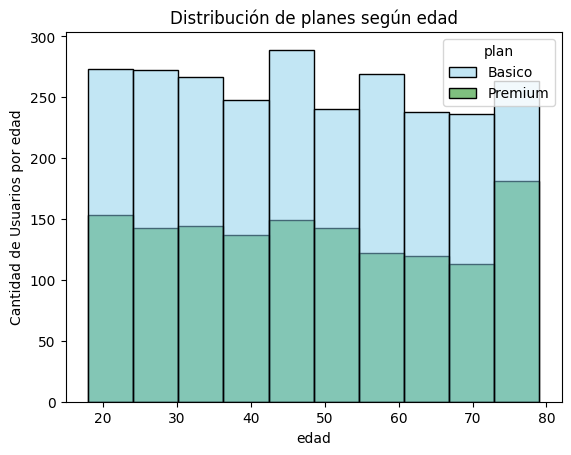

In [33]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=10)
plt.title('Distribución de planes según edad')
plt.xlabel('edad')
plt.ylabel('Cantidad de Usuarios por edad')
plt.show()


💡Insights: 
-"La distribución de edad es simétrica, con un pico entre los 40 y 50 años. Ambos planes mantienen proporciones similares en todos los rangos de edad, aunque se observa una leve preferencia por el plan Premium en usuarios mayores de 70 años."

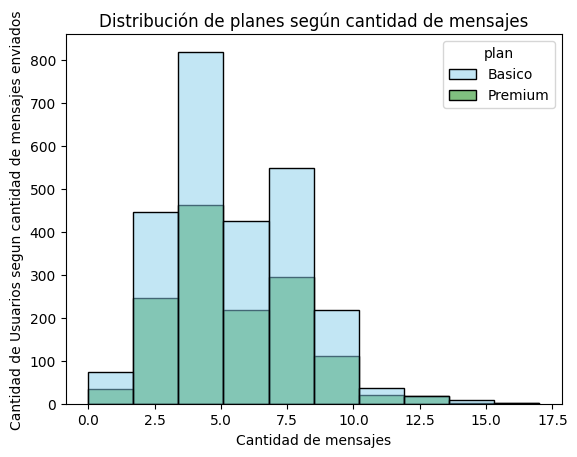

In [34]:

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=10)
plt.title('Distribución de planes según cantidad de mensajes')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de Usuarios segun cantidad de mensajes enviados')
plt.show()

# Histograma para visualizar la cant_mensajes


💡Insights: 
- La distribución de la cantidad mensajes tiene un sesgo hacia la derecha, con un pico entre los 3 y 5 mensajes. El uso entre planes en rangos bajos de cantidad de mensajes son proporcionales, existiendo una mayor presencia de Premium en usuarios con más de 10 mensajes

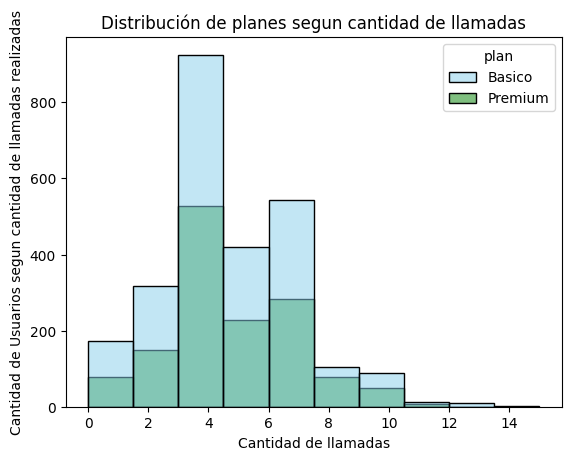

In [35]:

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=10)
plt.title('Distribución de planes segun cantidad de llamadas')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de Usuarios segun cantidad de llamadas realizadas')
plt.show()

# Histograma para visualizar la cant_llamadas


💡Insights: 
- La distribución de la cantidad llamadas tiene un sesgo hacia la derecha, con un pico entre las 3 y 4 llamadas. El uso entre planes en rangos bajos de cantidad de llamadas son proporcional, existiendo una mayor presencia de Premium en usuarios con más de 8 llamadas

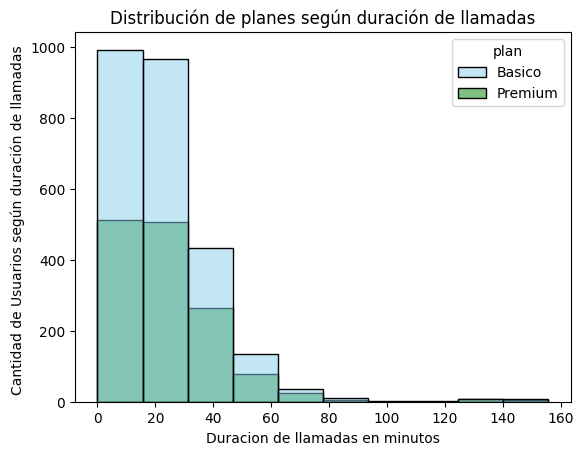

In [36]:
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], bins=10)
plt.title('Distribución de planes según duración de llamadas')
plt.xlabel('Duracion de llamadas en minutos')
plt.ylabel('Cantidad de Usuarios según duración de llamadas ')
plt.show()
# Histograma para visualizar la cant_minutos_llamada


💡Insights: 
- La distribución de la Duracion en minutos de llamadas tiene un sesgo hacia la derecha, con un pico entre los 0 y 30 minutos de llamadas. El uso entre planes en rangos bajos de duración de llamadas en minutos son proporcional, existiendo una mayor presencia de Premium en usuarios sobre los 30 minutos de duración de llamadas. 

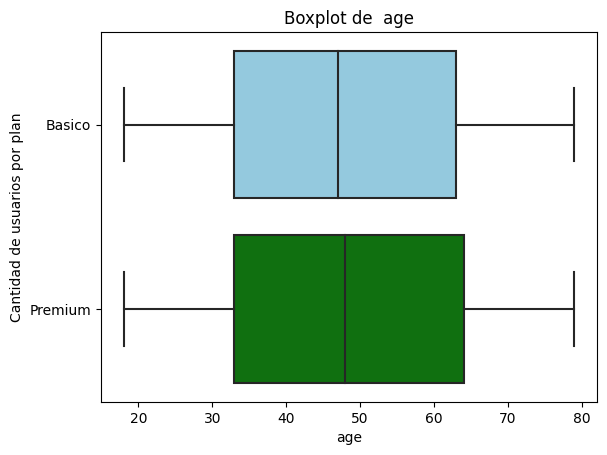

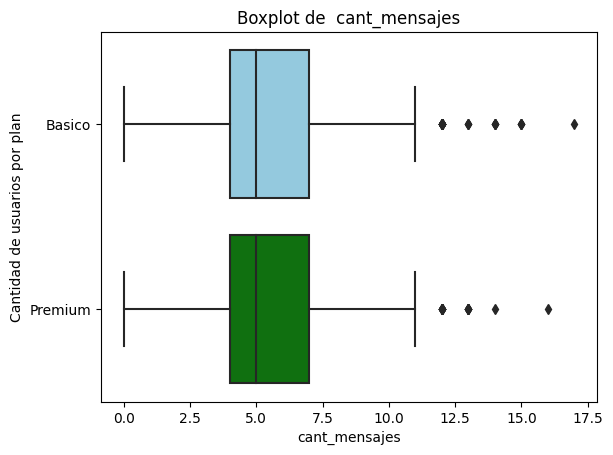

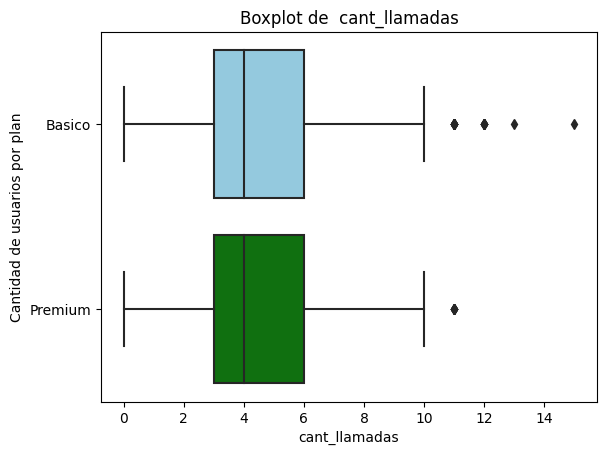

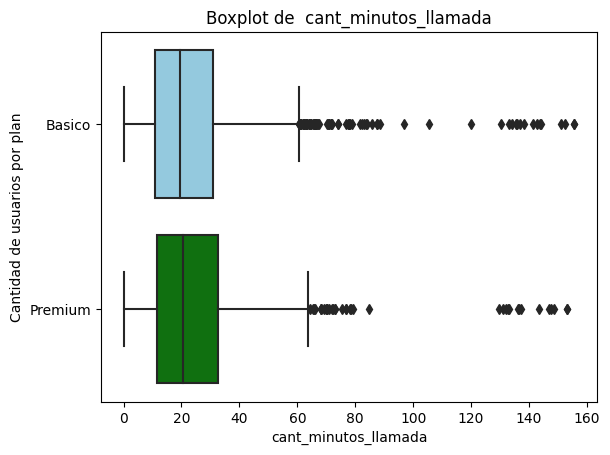

In [37]:

# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for columna in columnas_numericas:
    sns.boxplot(data=user_profile,x=columna,y='plan',palette=['skyblue', 'green'])
    plt.title (f'Boxplot de  {columna}')
    plt.xlabel(columna)
    plt.ylabel("Cantidad de usuarios por plan")
    plt.show()



💡Insights: 
- Age: En botplox no presenta outliers,la distribución es similar en ambos planes, la mediana en p.Básico es levente menor y sus valores extremos son similares. **La edad no parece ser un diferenciador fuerte entre los usuarios de ambos planes, no se debería tomar la edad como segmento clave**
- cant_mensajes: En botplox presenta outliers en el extemo superior de ambos planes, con un leve aumento en p.Básico, son casos aislados, la mediana y distribución son similares. **La cantidad de mensajes que utilizan los usuarios en ambos planes estan por debajo de su limite, los usuarios no aprovechan esta caracteristica del plan, por lo que enfocarse en otra caracteristicas del plan para  aumentar la migración sería mas certero**
- cant_llamadas: En botplox presenta mayor cantidad de outliers en su extremo superior en plan Básico, son casos aislados, su distribución es similar en ambos planes **usuarios del plan basico podrían estar pagando extra por su trafico en cantidad de llamadas, ofrecer una migración a plan premium puede ser una oportunidad de negocio**
- cant_minutos_llamada:  En botplox presenta mayor cantidad de outliers en su extremo superior en ambos planes, con un claro sesgo a la derecha, su distribución es similar en ambos planes **Los usuarios de ambos planes utilizan mas minutos en sus llamadas, La migración de plan sería oportuna para el negocio como para el cliente del plan Básico que podría estar pagando altas facturas, esta caracteristica seria un buen enfoque para incentivar la motivación de migración de planes** 

In [38]:
# Calcular límites con el método IQR


columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']
Q1= user_profile[columnas_limites].quantile (0.25)
Q3= user_profile[columnas_limites].quantile (0.75)
IQR= Q3-Q1
Límite_superior = Q3 + (1.5 * IQR)
Límite_inferior = Q1 - (1.5 * IQR)
print(f"IQR:\n{IQR} \nlímite Superior:\n {Límite_superior}\nlímite inferior:\n {Límite_inferior}")



IQR:
cant_mensajes            3.000
cant_llamadas            3.000
cant_minutos_llamada    20.295
dtype: float64 
límite Superior:
 cant_mensajes           11.5000
cant_llamadas           10.5000
cant_minutos_llamada    61.8575
dtype: float64
límite inferior:
 cant_mensajes           -0.5000
cant_llamadas           -1.5000
cant_minutos_llamada   -19.3225
dtype: float64


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: los outliers existentes (MAX:17 mensajes) sobre el límite superior (11.5 mensajes) son datos considerados reales, se mantendrán dentro del análisis. 
- cant_llamadas: los outliers existentes (MAX:15 llamadas) sobre el límite superior (10.5 llamadas) son datos considerados reales, se mantendrán dentro del análisis. 
- cant_minutos_llamada: los outliers existentes (MAX:155.69 minutos) sobre el límite superior (61.86 mensajes minutos) son datos considerados reales, se mantendrán dentro del análisis. 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:

condiciones = [(user_profile ['cant_llamadas'] < 5 ) & (user_profile ['cant_mensajes'] < 5 ), (user_profile ['cant_llamadas'] < 10 ) & (user_profile ['cant_mensajes'] < 10 )]
resultados = [('Bajo uso'),('Uso medio')]

user_profile['grupo_uso'] = np.select (condiciones, resultados, default = 'Alto uso')

In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
condiciones = [(user_profile ['age'] < 30 ) , (user_profile ['age'] < 60)]
resultados = [('Joven'),('Adulto')] 

user_profile ['grupo_edad'] = np.select ( condiciones, resultados, default = 'Adulto Mayor') # Crear columna grupo_edad


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

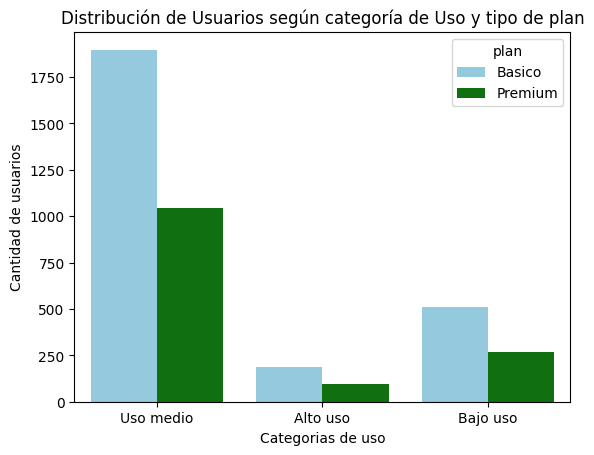

In [44]:
# Visualización de los segmentos por uso

sns.countplot(data= user_profile, x = 'grupo_uso', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Usuarios según categoría de Uso y tipo de plan')
plt.xlabel('Categorias de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

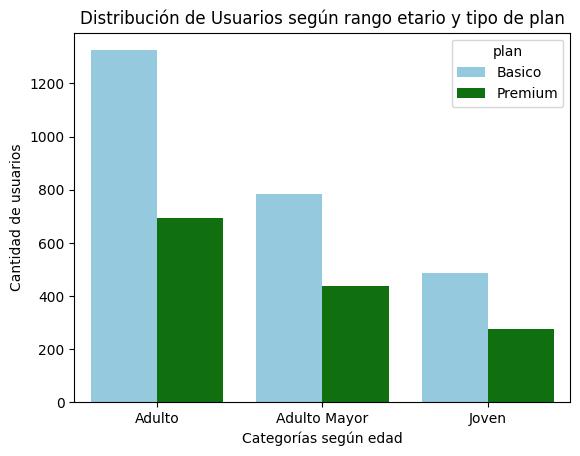

In [45]:
sns.countplot(data= user_profile, x = 'grupo_edad', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Usuarios según rango etario y tipo de plan')
plt.xlabel('Categorías según edad')
plt.ylabel('Cantidad de usuarios')
plt.show()
# Visualización de los segmentos por edad



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.


**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- **RP**

- **En el DF users, las columnas "city" y "churn_date" mantienen nulos, con una proporción del 11,7% y 88,3% respectivamente.
RP En el DF usage, las columnas "duration","length" y "date" mantienen nulos, con una proporción del 55%, 44,7% y 0,01% respectivamente, evaluados e intevenidos por ser nulos de tipo MAR**

**Existencia de valores invalidos, columnas como:  "city" presencia de sentinels ("?") que fueron reemplazados por Nan; "age" presencia de sentinels (-999) reemplazados con el valor de la mediana de los datos; "reg_date" presencia de año erronéo (2026), se reemplazaron por Nan.**

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

- **RP**

- **Agrupe los datos según su edad y tipo de plan en categorías de "joven", "adulto"," adulto mayor" siendo el segmento de "Adultos" con mas clientes, con mas de 1750 usuarios adultos en plan básico. La distribución de Usuarios de distintas edades según su plan es simetrica, la edad no es un rango diferenciador de uso resultado del analisis de variables claves de los datos**

- **Agrupe también según su uso y tipo de plan en categorías de "uso Bajo", "uso medio" y "Alto uso" donde la mayor cantidad de clientes mantiene un uso medio (< a 10 llamadas y mensajes, pero > a 5) con mas de 1750 usuarios en plan básico y 1000 usuarios de plan premium aproximadamente**

- **Analicé variables claves según el tipo de plan a traves de visualizaciones como botplox e histogramas que demuestran la distribución simetrica de las edades de los clientes con un pequeño aumento de usuarios entre 70 y 80 años, la cantidad de mensajes no supera los límites de su tipo de plan, a diferencia de la cantidad de minutos utilizados, que mantiene casos que superan en su plan básico sus limites de 100 minutos como en el caso max de 150 minutos utilizados.** 

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
 **RP**

  **Segmentos de "uso medio" y "Alto uso" son valiosos para una oportunidad de negocio. La propuesta de migración de plan Básico a plan Premium es oportuna para clientes que superen sus límites de minutos para llamadas que le entrega su plan actual en segmento de uso medio por la presencia de mas de 1750 usuarios (segmento mayor) y en segmento de Alto uso (segmento menor) quienes podrían estar pagando más en sus facturas** 
  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
**RP**

  -**Presencia de outliers en columna edad (-999), estos fueron imputados con la mediana de la columna, por ser valores erroneos que influyen en el estudio**

  -**Presencia de datos extremos para las columnas con cantidad de mensajes, llamadas y minutos de llamadas según la distibución del resto de los datos, pero son completmante reales dentro de los servicios que mantiene su plan, necesarios para analizar el comportamiento de los clientes**

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

- **Incentivar a clientes con alto flujo de minutos utilizados a plan premium, superan los limites ofrecidos en su plan básico (100)**

- **Evaluar la cantidad de mensajes incluidos, no son valorados por los clientes, recomiendo mejorar plan Básico con aumento de minutos incluidos ademas de no enfocar estrategias de este atributo**

- **Recomienda ampliar análisis a comportamiento de clientes según los GBs incluídos para evaluar como se consume este atributo y encontrar patrornes para nuevas desiciones claves para el negocio**


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

- Nulos en city (11.7%) y churn_date (88.3%)
- Valor sentinel -999 en columna age imputado con mediana
- Fecha inválida en reg_date (año 2026) corregida

🔍 **Segmentos por Edad**
- los usuarios se distribuyen en "jovenes", "adultos" y "adultos mayores" la distribución entre planes es simetríca.
- La edad no influye en la elección de un tipo de plan, aunque los adultos mayores sobre los 70 años demuestran un aumento en el uso del plan premium.


📊 **Segmentos por Nivel de Uso**
- los usuarios se distribuyen en "uso bajo", "uso medio" y "Alto uso", los clientes se concentran en la categoría de uso medio con un plan básico.
- Usuarios de planes básicos superan sus niveles de minutos íncluidos exisitendo casos de uso máximo de 155 minutos.


➡️ Esto sugiere que: 
-**clientes presentes en segmentos de "Alto uso" y algunos en "uso medio" que utilizan planes básicos estan pagando demas en sus facturas por el exceso de minutos consumidos mensualmente

💡 **Recomendaciones**
- Demostrar la conveniencia de la migración a plan premium por alto consumo de minutos incluidos a clientes del segmento "Alto uso".
- Proponer oferta de descuento a clientes del segmento "uso medio" que migren de plan.
- Ampliar análisis de clientes según uso de GBs incluídos para encontrar patrones en este servicio beneficos en nuevas desiciones de negocio.
- Crear nuevo plan que contemple una disminucion la cantidad de mensajes y aumente los minutos incluídos.
- ofrecer incentivos a clientes mayores de 70 años para mantener su permanencia en plan premium

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`